## Check BGC-Argo floats distribution split

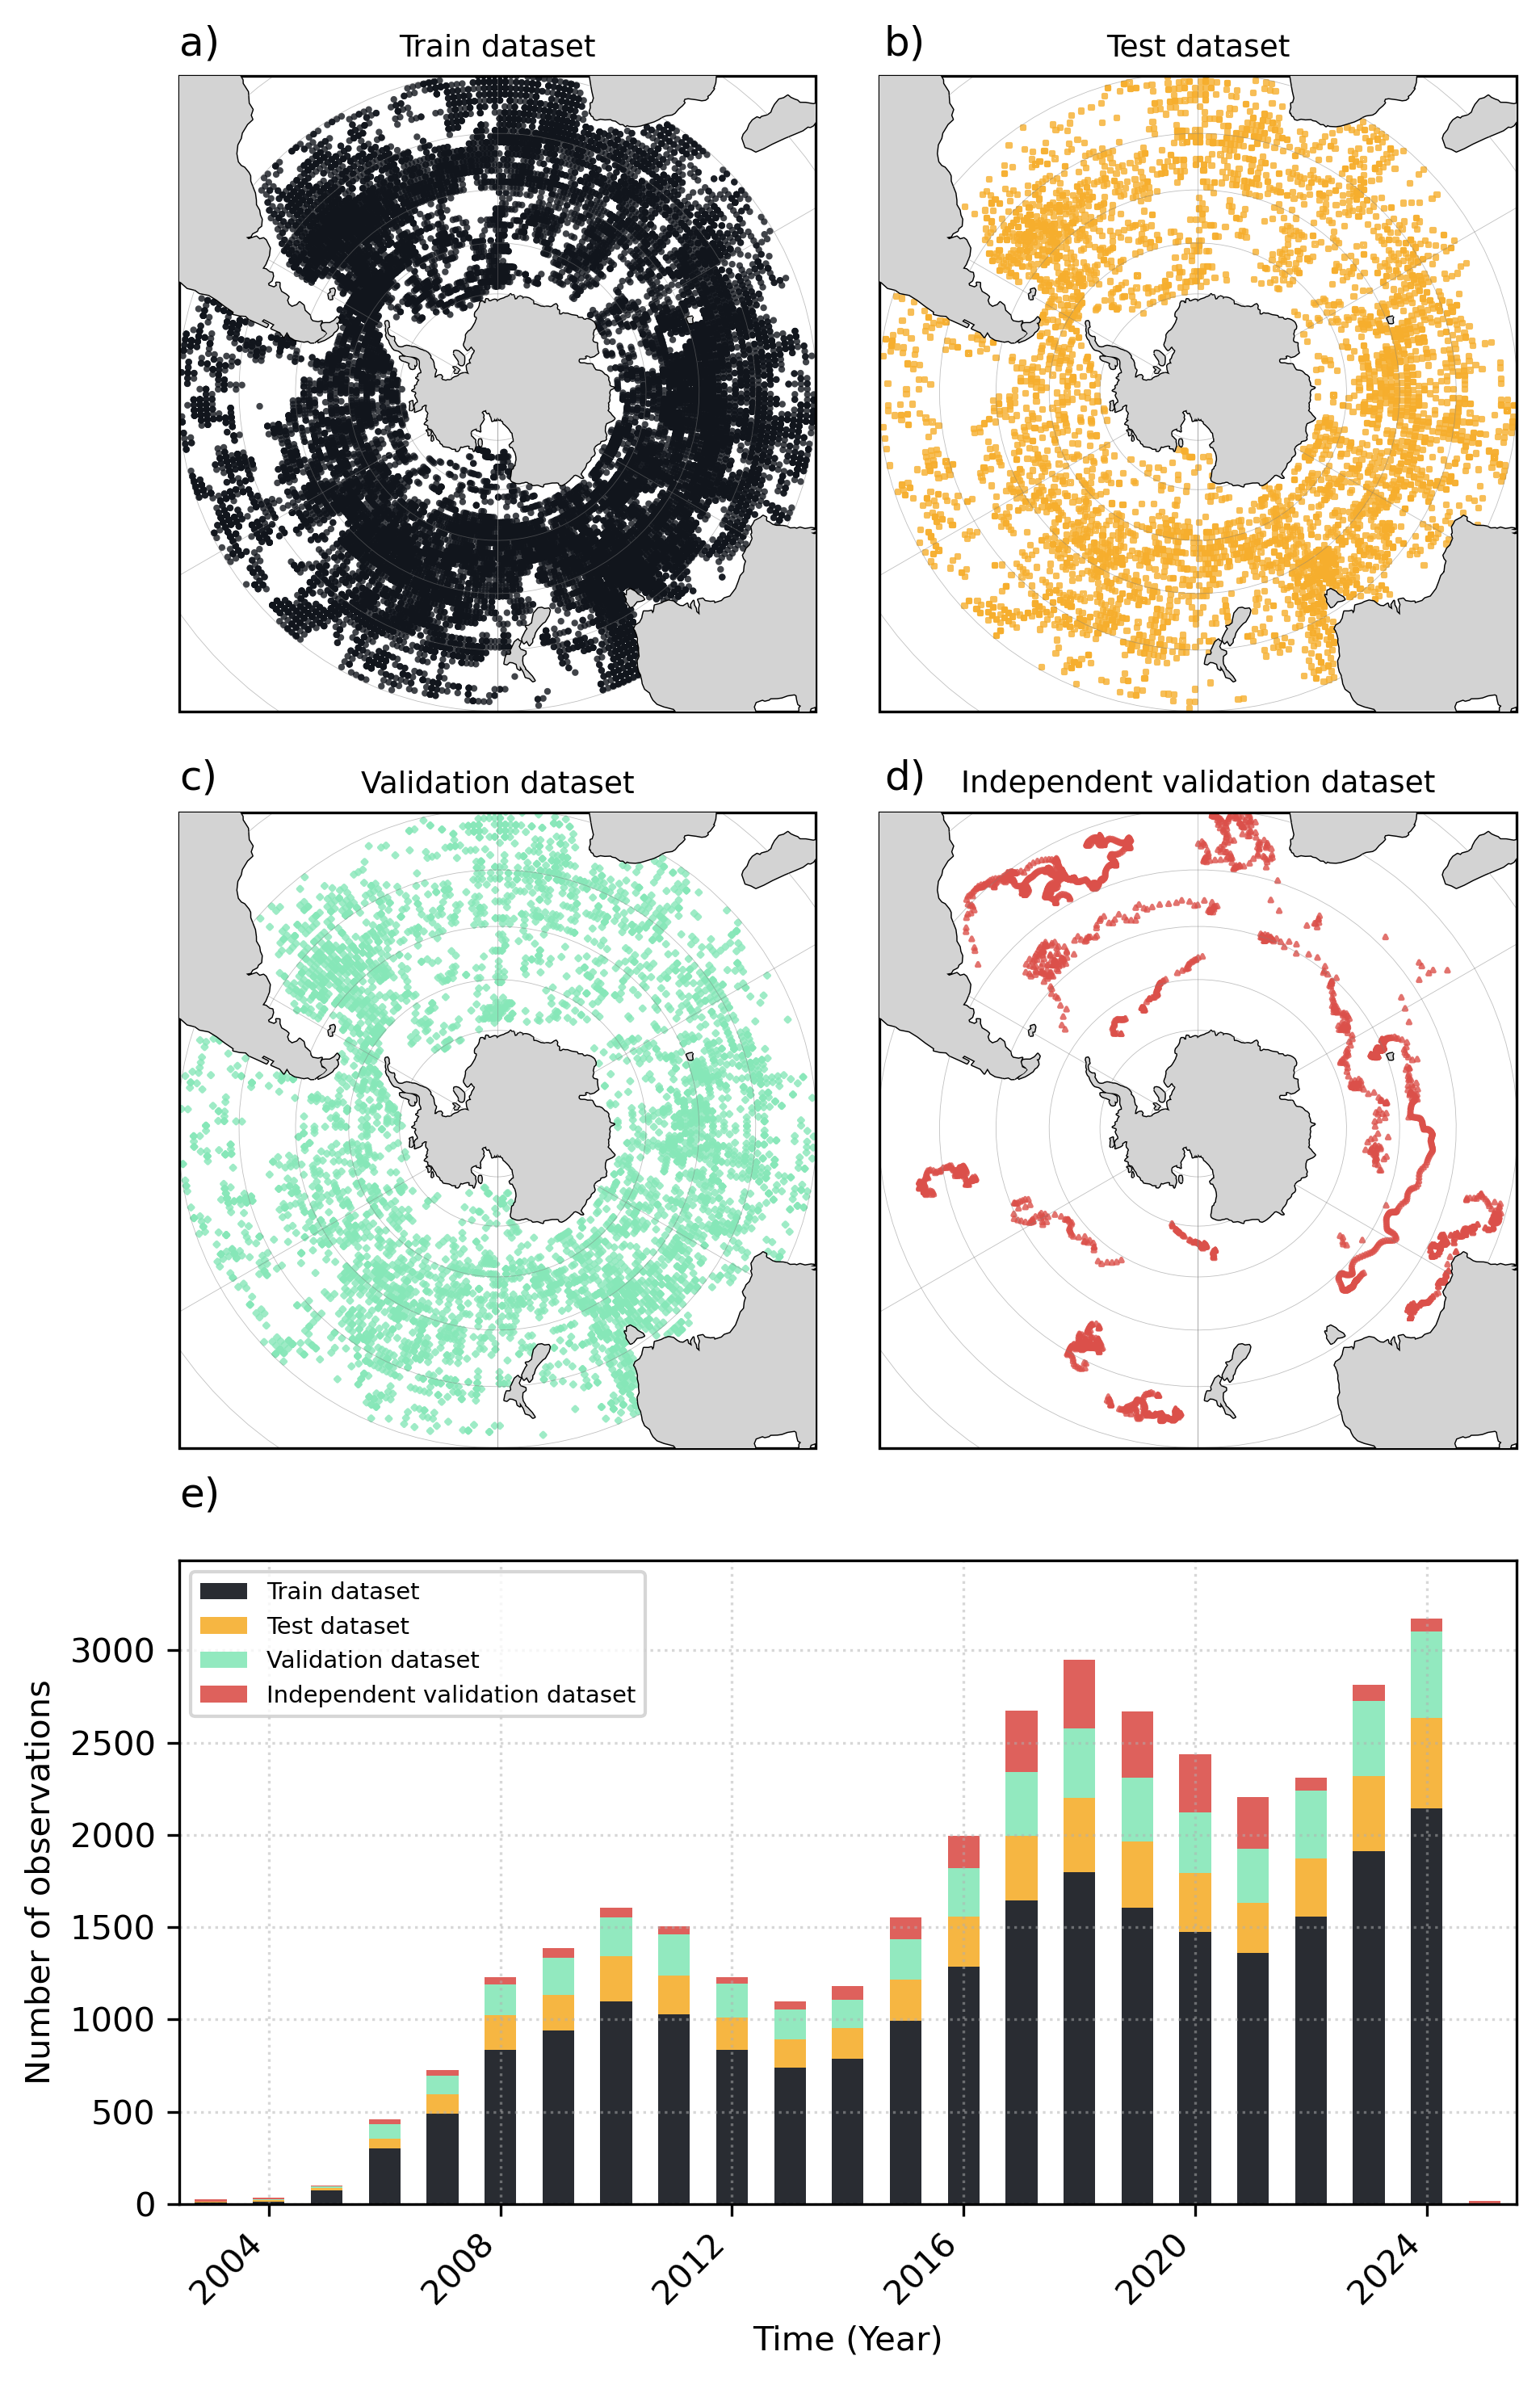

[DONE] Saved figure → figs/HDBSCAN_split_overview.png


In [5]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import os

# ===============================================================
# CONFIG
# ===============================================================
OUTFIG = "figs/HDBSCAN_split_overview.png"
os.makedirs(os.path.dirname(OUTFIG), exist_ok=True)

LAT_EXTENT = [-180, 180, -90, -30]  # map extent

# ===============================================================
# LOAD DATASETS
# ===============================================================
datasets = {
    "train_data": pd.read_csv(
        "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_FLOATS_v2/processing_steps/FLOATS_pco2_train_data.csv"
    ),
    "test_data": pd.read_csv(
        "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_FLOATS_v2/processing_steps/FLOATS_pco2_test_data.csv"
    ),
    "validation_data": pd.read_csv(
        "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_FLOATS_v2/processing_steps/FLOATS_pco2_validation_data.csv"
    ),
    "independent_validation_data": pd.read_csv(
        "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_FLOATS_v2/processing_steps/independent_validation/pco2_independent_validation_data.csv"
    ),
}

# ===============================================================
# FIX COORDINATE COLUMN NAMES
# ===============================================================
for key, df in datasets.items():
    # HDBSCAN splits typically have latitude/longitude already
    if "lat_center" in df.columns and "latitude" not in df.columns:
        df.rename(columns={"lat_center": "latitude"}, inplace=True)
    if "lon_center" in df.columns and "longitude" not in df.columns:
        df.rename(columns={"lon_center": "longitude"}, inplace=True)

# ===============================================================
# ENSURE month_center EXISTS (ROBUST) + NORMALIZE TO MONTH-START
# ===============================================================
for key, df in datasets.items():

    # 1) month_center already exists
    if "month_center" in df.columns:
        df["month_center"] = pd.to_datetime(df["month_center"], errors="coerce")

    # 2) try datetime
    elif "datetime" in df.columns:
        df["month_center"] = pd.to_datetime(df["datetime"], errors="coerce")

    # 3) try time
    elif "time" in df.columns:
        df["month_center"] = pd.to_datetime(df["time"], errors="coerce")

    # 4) build from components if present
    elif {"year", "month", "day"}.issubset(df.columns):
        df["month_center"] = pd.to_datetime(
            dict(year=df["year"], month=df["month"], day=df["day"]),
            errors="coerce"
        )

    else:
        raise ValueError(
            f"{key}: cannot build month_center. Available columns: {list(df.columns)}"
        )

    # Normalize to monthly timestamp (pipeline convention = month-start)
    df["month_center"] = df["month_center"].dt.to_period("M").dt.to_timestamp(how="start")
    df.dropna(subset=["month_center"], inplace=True)

# ===============================================================
# PLOTTING
# ===============================================================
def plot_data(datasets_dict):

    colors = ['#11151C', '#F6AE2D', '#86E7B8', '#DB504A']
    markers = ['o', 's', 'D', '^']
    label_map = {
        "train_data": "Train dataset",
        "test_data": "Test dataset",
        "validation_data": "Validation dataset",
        "independent_validation_data": "Independent validation dataset"
    }

    ordered_keys = ["train_data", "test_data", "validation_data", "independent_validation_data"]

    fig = plt.figure(figsize=(6, 10), dpi=300)
    gs = gridspec.GridSpec(4, 2, height_ratios=[1, 1, -0.12, 1])

    # === MAPS (4 PANELS) ===
    for i, key in enumerate(ordered_keys):
        row, col = divmod(i, 2)

        ax = fig.add_subplot(gs[row, col], projection=ccrs.SouthPolarStereo())
        ax.set_extent(LAT_EXTENT, crs=ccrs.PlateCarree())
        ax.coastlines(resolution='110m', linewidth=0.7)
        ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=12)
        ax.gridlines(draw_labels=False, linewidth=0.2, color='gray', alpha=0.5)

        df = datasets_dict[key]

        if "latitude" not in df.columns or "longitude" not in df.columns:
            raise ValueError(f"{key} is missing latitude/longitude columns.")

        ax.scatter(
            df["longitude"], df["latitude"],
            s=1,
            facecolors="none",
            edgecolors=colors[i],
            marker=markers[i],
            alpha=0.8,
            transform=ccrs.PlateCarree()
        )

        ax.set_title(label_map[key], fontsize=9)

    # === YEARLY STACKED HISTOGRAM ===
    ax_hist = fig.add_subplot(gs[3, :])

    hist_keys = ordered_keys

    min_year = min(datasets_dict[k]["month_center"].dt.year.min() for k in hist_keys)
    max_year = max(datasets_dict[k]["month_center"].dt.year.max() for k in hist_keys)

    all_years = pd.period_range(start=f"{min_year}", end=f"{max_year}", freq="Y")
    all_years_datetime = all_years.to_timestamp()

    bar_width = 200  # days (wide since yearly)
    bottom = np.zeros(len(all_years_datetime))

    for key, color in zip(hist_keys, colors):
        df = datasets_dict[key]

        yearly_counts = (
            df["month_center"]
            .dt.to_period("Y")
            .value_counts()
            .reindex(all_years, fill_value=0)
            .sort_index()
        )

        ax_hist.bar(
            all_years_datetime,
            yearly_counts.values,
            width=bar_width,
            bottom=bottom,
            color=color,
            alpha=0.9,
            label=label_map[key]
        )
        bottom += yearly_counts.values

    ax_hist.set_xlim(
        all_years_datetime.min() - pd.Timedelta(days=200),
        all_years_datetime.max() + pd.Timedelta(days=200)
    )

    ymax = bottom.max()
    ax_hist.set_ylim(0, ymax * 1.1 if ymax > 0 else 1)

    ax_hist.set_xlabel("Time (Year)")
    ax_hist.set_ylabel("Number of observations")
    ax_hist.grid(True, linestyle=":", alpha=0.5)
    ax_hist.legend(loc="upper left", fontsize=7)

    plt.setp(ax_hist.get_xticklabels(), rotation=45, ha="right")

    # === PANEL TAGS ===
    tags = ["a)", "b)", "c)", "d)", "e)"]
    positions = [
        (0.05, 0.967), (0.535, 0.967),
        (0.05, 0.664), (0.535, 0.664),
        (0.05, 0.368)
    ]
    for (x, y), tag in zip(positions, tags):
        fig.text(x, y, tag, fontsize=12)

    plt.subplots_adjust(left=0.05, right=0.97, top=0.96, bottom=0.08, wspace=0.1)

    plt.savefig(OUTFIG, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"[DONE] Saved figure → {OUTFIG}")


plot_data(datasets)


## BGC-Argo independent validation

In [11]:
import pandas as pd

df = pd.read_csv(
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_FLOATS_v2/models/30S/MC_ensemble/independent_predictions/MC_FLOATS_independent_validation_predictions.csv"
)

In [12]:
df

,month_center,lat_center,lon_center,depth,MLD,ARMOR3D_temperature,ARMOR3D_salinity,FLOATS_pco2_median,FLOATS_pco2_error_median,FLOATS_temperature_median,...,pco2_pred_MCmodel_992,pco2_pred_MCmodel_993,pco2_pred_MCmodel_994,pco2_pred_MCmodel_995,pco2_pred_MCmodel_996,pco2_pred_MCmodel_997,pco2_pred_MCmodel_998,pco2_pred_MCmodel_999,pco2_pred_MCmodel_1000,ensemble_std
0,2003-09-01,-35.5,-162.5,0.0,53.45,15.0620,35.2185,339.031494,18.259001,15.380500,...,344.05313,322.49570,336.59550,344.88742,343.48172,345.05222,338.60114,340.17282,344.92920,6.213733
1,2003-10-01,-35.5,-162.5,0.0,57.25,15.1555,35.1665,336.919983,18.228001,15.775000,...,351.90894,334.18655,329.21304,347.09592,348.90620,355.61420,347.86890,353.87730,337.77545,6.317601
2,2003-08-01,-35.5,-161.5,0.0,93.10,14.6435,35.1210,339.139999,18.066750,15.361249,...,345.99426,335.47290,333.54108,354.12480,347.35516,346.20200,346.70410,343.59310,337.84036,6.613591
3,2003-09-01,-35.5,-161.5,0.0,68.65,14.9390,35.1900,337.017761,17.990501,15.275500,...,344.12762,323.89010,335.30800,343.87234,343.32803,343.95718,340.45215,340.90143,344.32565,6.074552
4,2003-10-01,-35.5,-161.5,0.0,37.70,15.3255,35.1340,336.453003,18.209999,15.927500,...,349.61770,333.82745,330.49310,345.80386,348.72968,356.72858,347.47504,353.39264,337.45074,6.392151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1291,2024-01-01,-30.5,-36.5,0.0,23.50,22.6340,35.8940,422.007996,25.484000,22.176453,...,421.52707,423.74240,425.64716,421.66428,418.39987,423.95346,401.39343,406.07990,413.13205,8.919967
1292,2024-02-01,-30.5,-36.5,0.0,19.30,23.7910,35.7905,429.401001,25.327999,23.560463,...,436.46220,434.76505,435.04376,423.26886,435.69710,433.17972,415.31592,432.72940,427.65690,7.537657
1293,2024-03-01,-30.5,-36.5,0.0,26.40,24.0830,35.8870,432.535004,25.938999,24.403641,...,446.44090,438.66574,434.84796,424.13910,440.02927,438.83588,421.98590,443.80853,442.18960,7.391799
1294,2024-04-01,-30.5,-36.5,0.0,40.95,22.9715,36.0405,422.928986,26.481001,22.896458,...,431.27300,422.74576,423.71430,422.66788,432.00113,433.47852,411.94410,436.11505,436.37630,7.290632


Years present in dataset: [2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016
 2017 2018 2019 2020 2021 2022 2023 2024]


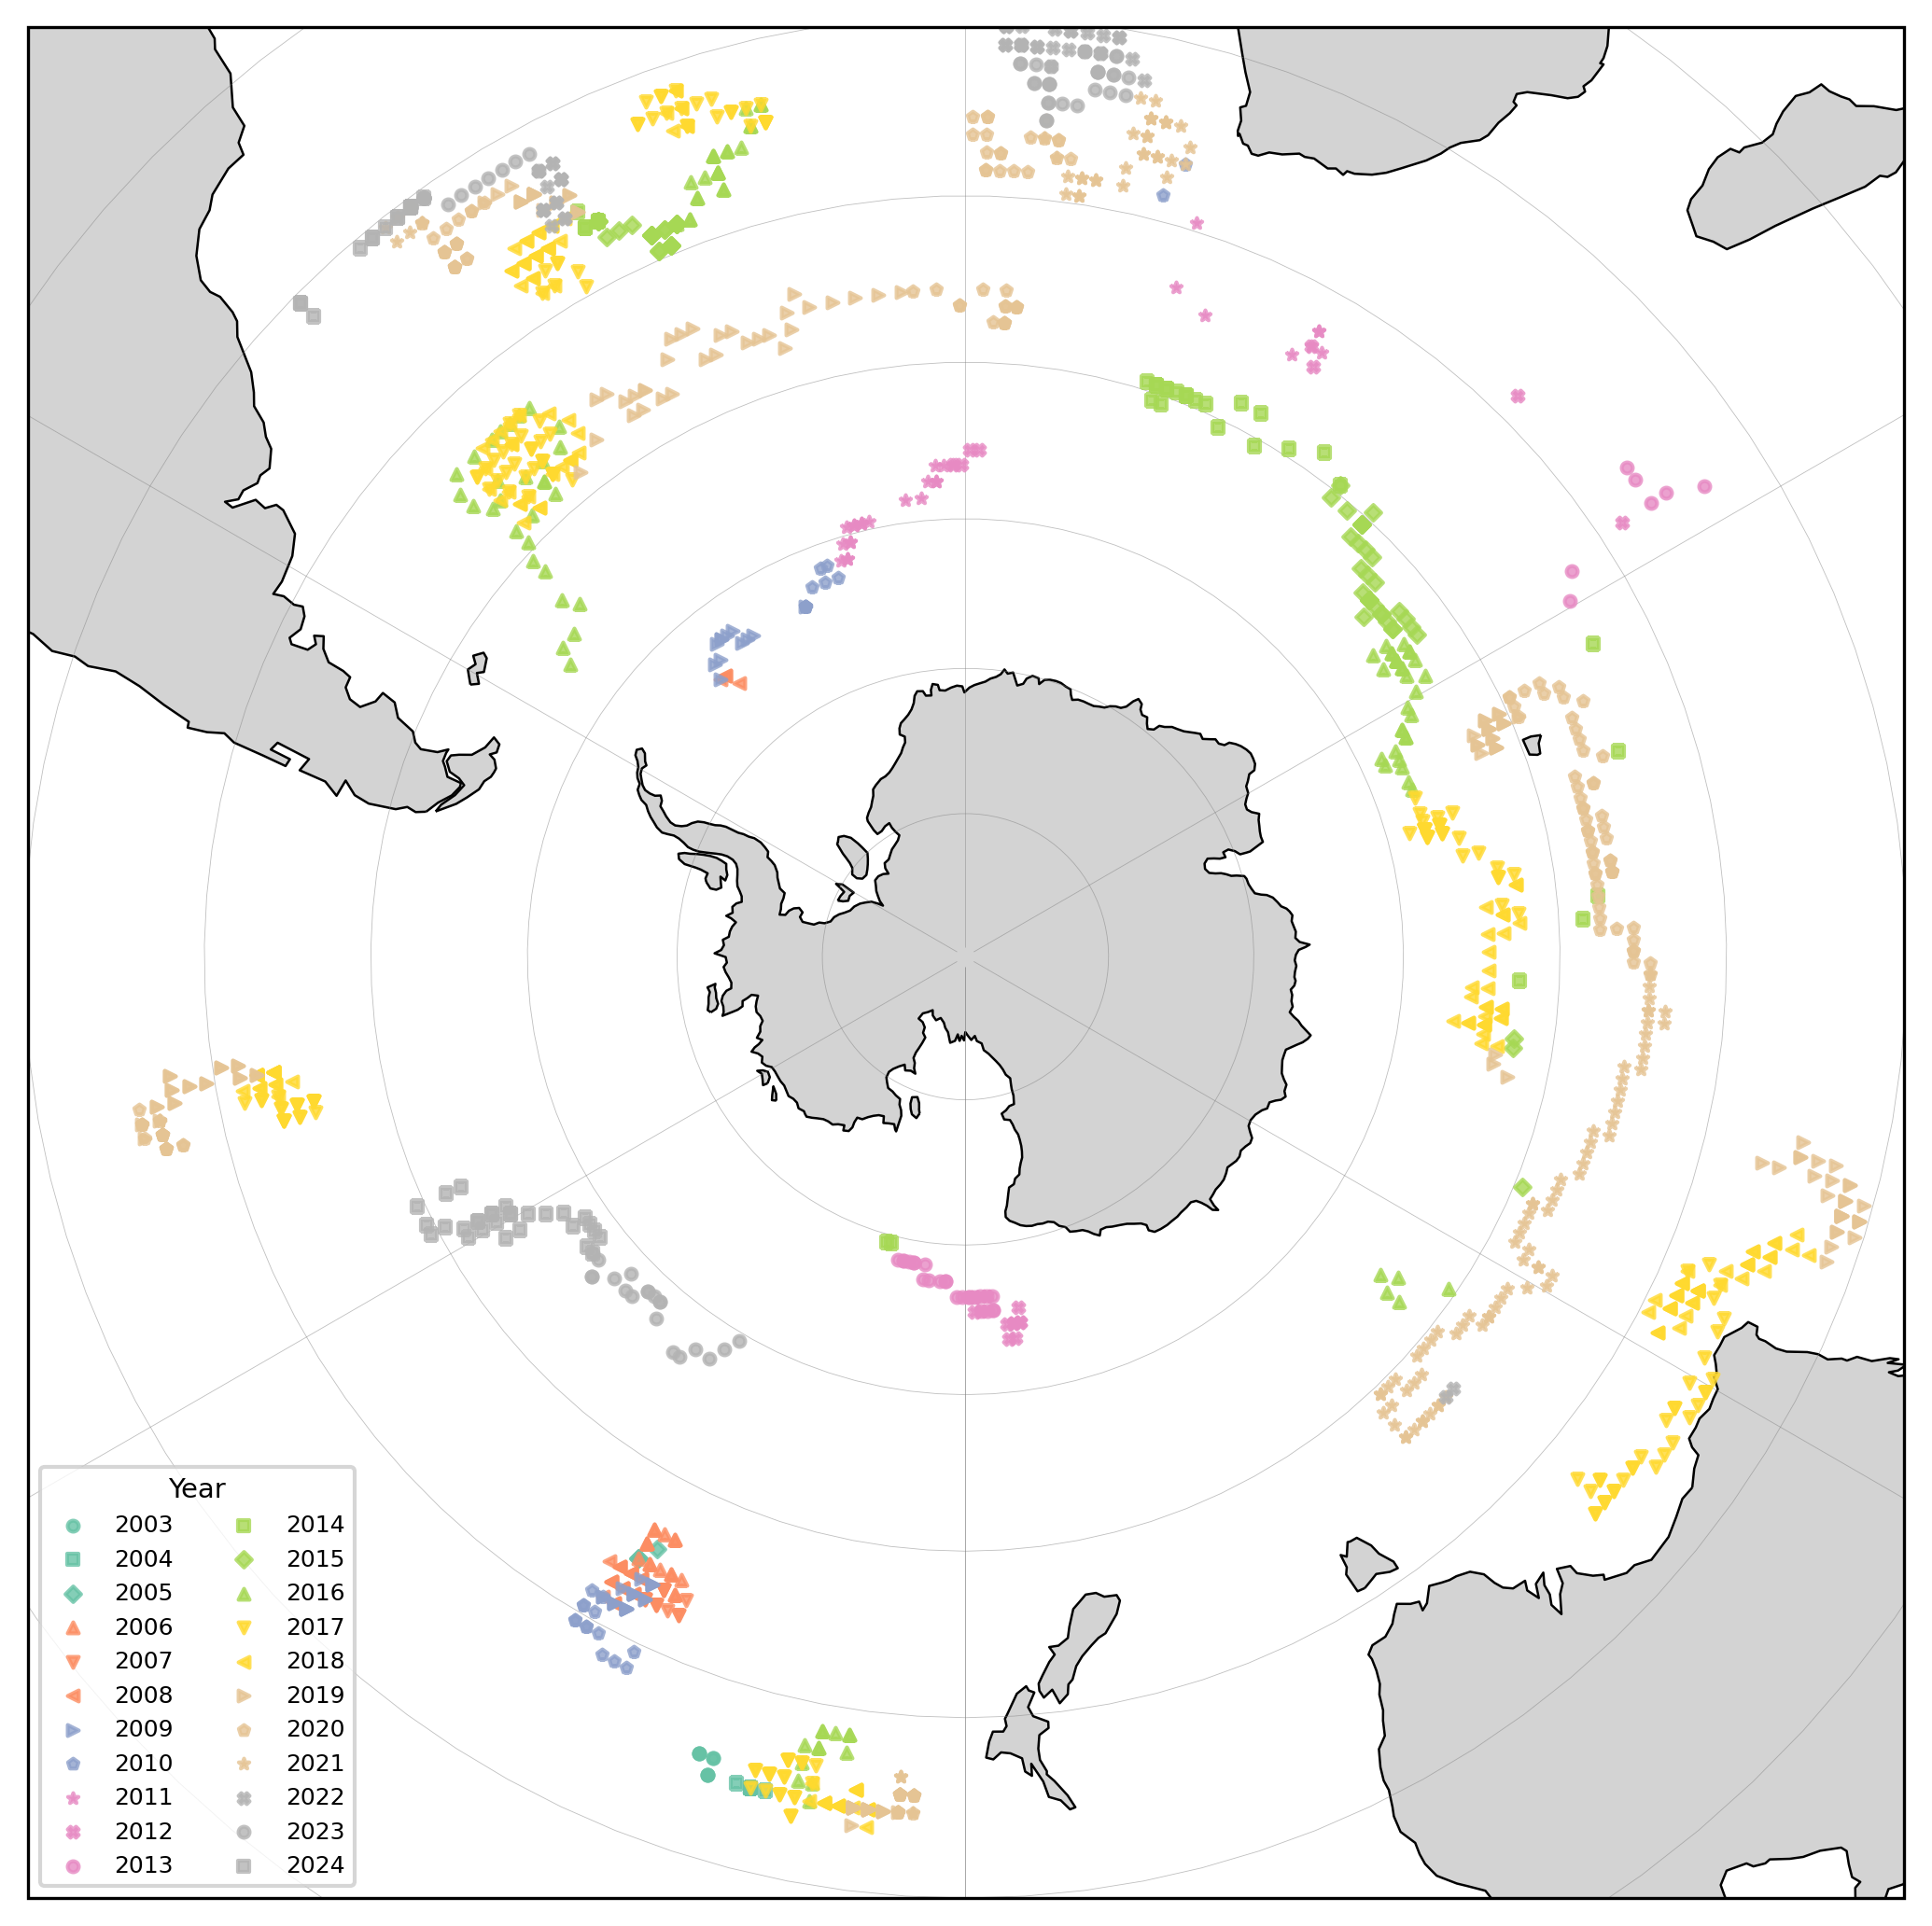

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# -------------------------------
# Convert month_center to datetime and extract year
# -------------------------------
df["month_center"] = pd.to_datetime(df["month_center"], errors="coerce")
df["year"] = df["month_center"].dt.year

# -------------------------------
# Drop rows with missing year or coordinates
# -------------------------------
df = df.dropna(subset=["year", "lat_center", "lon_center"])

# -------------------------------
# Unique years present in dataset
# -------------------------------
years = np.sort(df["year"].unique())
n_years = len(years)

print("Years present in dataset:", years)

# -------------------------------
# Set up map
# -------------------------------
fig = plt.figure(figsize=(7, 7), dpi=300)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -30], crs=ccrs.PlateCarree())

# Base map
ax.coastlines(resolution='110m', linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.gridlines(draw_labels=False, linewidth=0.2, color='gray', alpha=0.5)

# -------------------------------
# Colors & markers
# -------------------------------
colors = plt.cm.Set2(np.linspace(0, 1, n_years))
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'X']

# -------------------------------
# Plot per YEAR
# -------------------------------
for i, yr in enumerate(years):
    df_y = df[df["year"] == yr]

    ax.scatter(
        df_y['lon_center'],
        df_y['lat_center'],
        s=8,
        label=f"{int(yr)}",
        color=colors[i % len(colors)],
        marker=markers[i % len(markers)],
        transform=ccrs.PlateCarree(),
        zorder=2,
        alpha=0.8
    )

# -------------------------------
# Legend
# -------------------------------
ax.legend(
    title="Year",
    loc='lower left',
    fontsize=6,
    title_fontsize=7,
    ncol=2,
    frameon=True
)

# -------------------------------
# Save and display
# -------------------------------
plt.tight_layout()
plt.savefig("figs/validation_points_per_year.png", dpi=300, bbox_inches='tight')
plt.show()


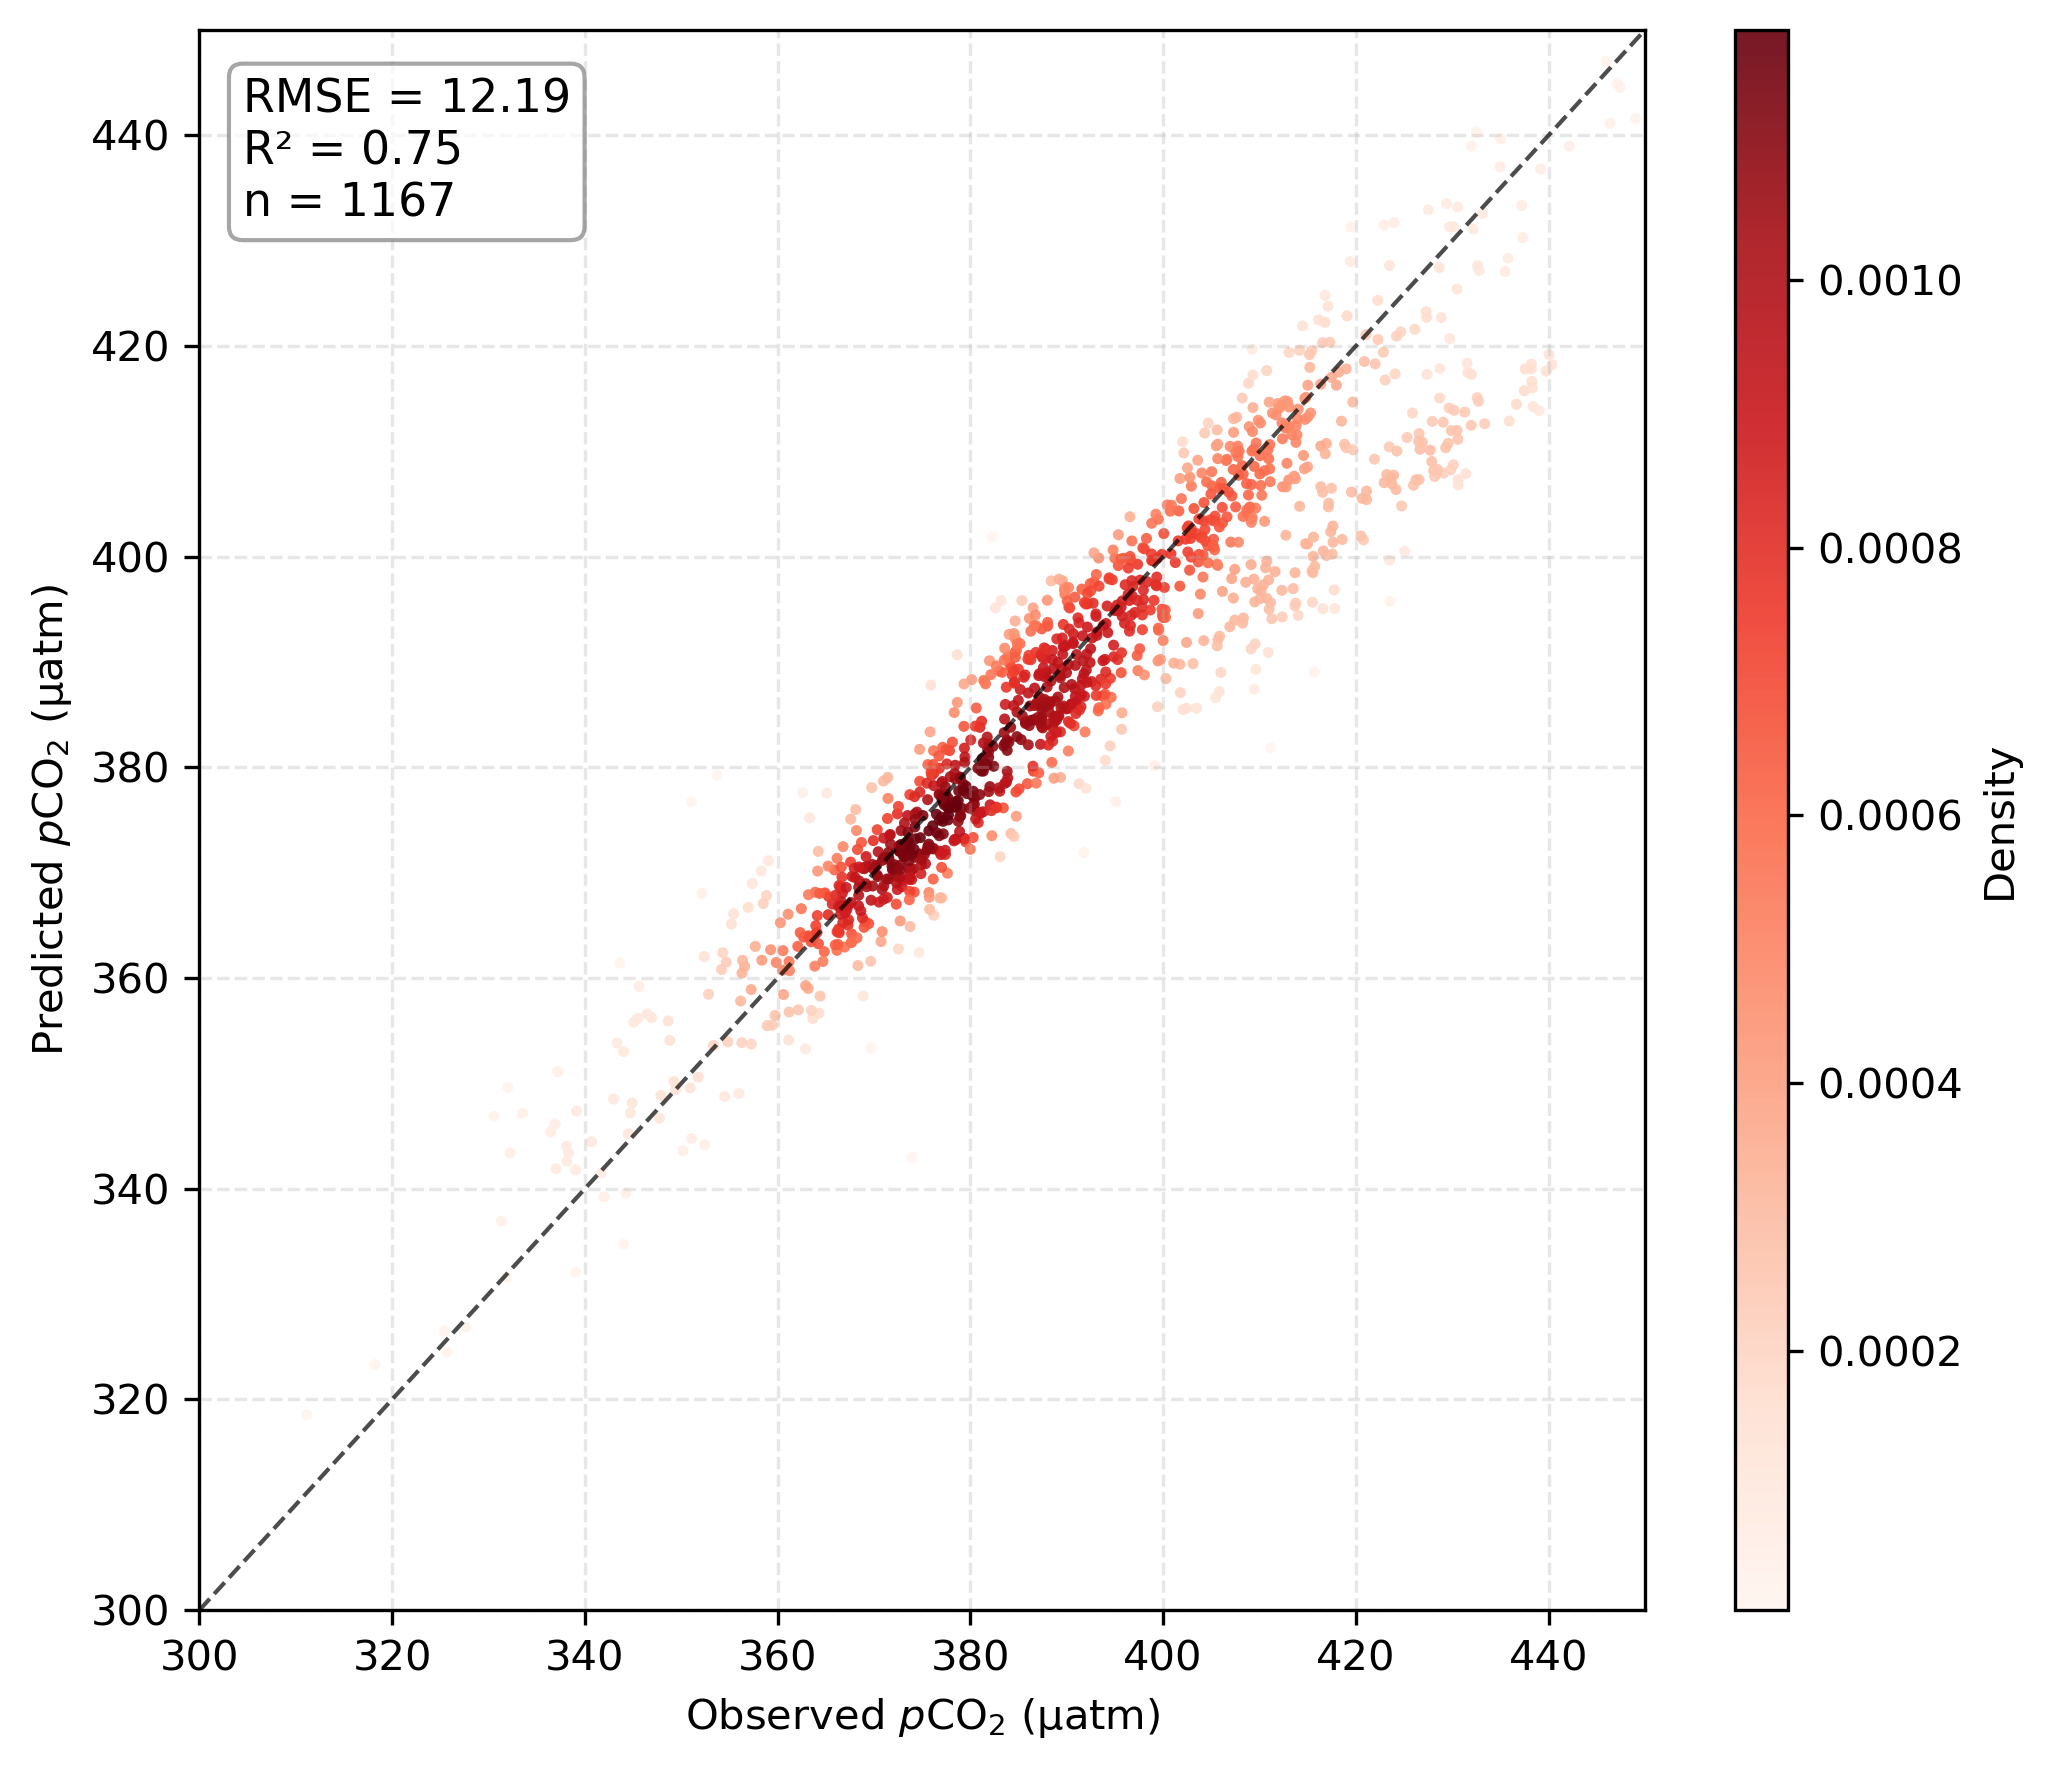

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import gaussian_kde

# -------------------------------
# Select only needed columns and drop NaNs
# -------------------------------
df_valid = df[['FLOATS_pco2_median', 'ensemble_pco2_pred']].dropna()

x = df_valid['FLOATS_pco2_median'].values
y = df_valid['ensemble_pco2_pred'].values
n = len(df_valid)

# -------------------------------
# Compute point density using KDE
# -------------------------------
xy = np.vstack([x, y])
density = gaussian_kde(xy)(xy)

# -------------------------------
# Plot
# -------------------------------
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

sc = ax.scatter(
    x, y,
    c=density,
    s=7,
    alpha=0.9,
    edgecolor='none',
    cmap='Reds'
)

# Labels
ax.set_xlabel(r"Observed $p\mathrm{CO}_2$ $\mathrm{(\mu atm)}$")
ax.set_ylabel(r"Predicted $p\mathrm{CO}_2$ $\mathrm{(\mu atm)}$")
ax.grid(True, ls='--', alpha=0.3)

# -------------------------------
# 1:1 line
# -------------------------------
min_pco2 = min(300, 300)
max_pco2 = max(450, 450)

ax.plot(
    [min_pco2, max_pco2],
    [min_pco2, max_pco2],
    'k--',
    lw=1,
    alpha=0.7
)

# Axis limits
ax.set_xlim(300, 450)
ax.set_ylim(300, 450)

# -------------------------------
# Colorbar
# -------------------------------
cbar = fig.colorbar(sc, ax=ax, label='Density', aspect=30)

# -------------------------------
# Metrics (NaN-safe, sklearn-safe)
# -------------------------------
rmse = np.sqrt(mean_squared_error(x, y))
r2 = r2_score(x, y)

# -------------------------------
# Stats box
# -------------------------------
stats_text = f"RMSE = {rmse:.2f}\nR² = {r2:.2f}\nn = {n}"

ax.text(
    0.03, 0.97, stats_text,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.7)
)

# -------------------------------
# Save and show
# -------------------------------
fig.tight_layout()
fig.savefig("figs/pco2_density_scatter.png", dpi=300, bbox_inches='tight')
plt.show()


In [15]:
# import numpy as np
# import pandas as pd
# from scipy.stats import linregress
# from sklearn.metrics import mean_squared_error, r2_score

# # Fit regression
# slope, intercept, r_value, p_value, std_err = linregress(x, y)

# # Define bins
# bins = np.arange(300, 410, 10)

# # Total number of points (for % calculation)
# N_total = len(x)

# # Pointwise bias
# point_bias = y - x
# bin_idx = np.digitize(x, bins)

# # -----------------------------------------------------------
# # 1. POINTWISE BIAS (Pred - Obs) + percentage of points
# # -----------------------------------------------------------
# pw_results = []
# for i in range(1, len(bins)):
#     mask = bin_idx == i
#     n_bin = np.sum(mask)
#     if n_bin > 0:
#         pw_mean = np.mean(point_bias[mask])
#         pct = (n_bin / N_total) * 100  # NEW
#         pw_results.append([f"{bins[i-1]}–{bins[i]}", pw_mean, n_bin, pct])

# pw_df = pd.DataFrame(pw_results, columns=["Bin (µatm)", "Mean Pointwise Bias (µatm)", "n", "% of dataset"])


# # -----------------------------------------------------------
# # 2. STRUCTURAL REGRESSION BIAS (Regression - 1:1)
# #    + percentage of points in the bin
# # -----------------------------------------------------------
# reg_results = []
# for i in range(len(bins)-1):
#     x_mid = (bins[i] + bins[i+1]) / 2
#     y_reg = slope * x_mid + intercept
#     diff = y_reg - x_mid

#     # % of data in this bin (same mask as above)
#     mask = (bin_idx == i+1)
#     pct = (np.sum(mask) / N_total) * 100  # NEW

#     reg_results.append([f"{bins[i]}–{bins[i+1]}", x_mid, diff, pct])

# reg_df = pd.DataFrame(reg_results, columns=["Bin (µatm)", "Bin Center", "Regression Bias (µatm)", "% of dataset"])


# # -----------------------------------------------------------
# # 3. Print results with explanations
# # -----------------------------------------------------------

# print("\n" + "="*70)
# print("POINTWISE BIAS (Predicted − Observed)")
# print("="*70)
# print("Meaning:")
# print(" This measures the actual model error in each bin.")
# print(" The % column tells you how much of the dataset falls in each bin.")
# print(" A high % means the bias in that bin strongly affects overall model behavior.\n")
# print(pw_df)

# print("\n" + "="*70)
# print("STRUCTURAL REGRESSION BIAS (Regression Line − 1:1 Line)")
# print("="*70)
# print("Meaning:")
# print(" This measures systematic bias independent of noise.")
# print(" The % column tells you how much of the dataset occupies each bin.")
# print(" A bin with very few points will have low influence on overall structural bias.\n")
# print(reg_df)



In [16]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy.stats import linregress

# # Fit regression line once
# slope, intercept, r_value, p_value, std_err = linregress(x, y)

# # Define 10-µatm bins from 300 to 400
# bins = np.arange(300, 410, 10)
# bin_centers = (bins[:-1] + bins[1:]) / 2

# # Assign each observed x to a bin
# bin_idx = np.digitize(x, bins)
# hist_counts = np.array([np.sum(bin_idx == i) for i in range(1, len(bins))])

# # Percentages for each bin
# N_total = len(x)
# hist_pct = (hist_counts / N_total) * 100

# # Pointwise bias (actual model error)
# point_bias = y - x

# # -----------------------------------------------------------
# # COMPUTE POINTWISE BIAS PER BIN
# # -----------------------------------------------------------
# pw_bias = []
# for i in range(1, len(bins)):
#     mask = (bin_idx == i)
#     if np.sum(mask) > 0:
#         pw_bias.append(np.mean(point_bias[mask]))
#     else:
#         pw_bias.append(np.nan)

# pw_bias = np.array(pw_bias)

# # -----------------------------------------------------------
# # COMPUTE STRUCTURAL REGRESSION BIAS PER BIN
# # -----------------------------------------------------------
# reg_bias = []
# for xc in bin_centers:
#     y_reg = slope * xc + intercept   # regression prediction at bin center
#     diff = y_reg - xc                # difference from 1:1
#     reg_bias.append(diff)

# reg_bias = np.array(reg_bias)

# # -----------------------------------------------------------
# # COMBINED HISTOGRAM + BIAS CURVE PLOT
# # -----------------------------------------------------------

# fig, ax1 = plt.subplots(figsize=(8, 5), dpi=300)

# # --- Histogram (primary axis) ---
# bar_width = bins[1] - bins[0]
# bars = ax1.bar(bin_centers, hist_counts, width=bar_width*0.9,
#                color='lightgray', edgecolor='k', alpha=0.6)

# #ax1.set_ylim(0, 40)
# ax1.set_xlabel('Observed pCO$_2$ (µatm)')
# ax1.set_ylabel('Count of observations')
# ax1.grid(True, ls='--', alpha=0.3)

# # --- Add % labels on top of each histogram bar ---
# for xc, height, pct in zip(bin_centers, hist_counts, hist_pct):
#     if height > 0:
#         ax1.text(xc, 0.5, f"{pct:.1f}%", ha='center', va='bottom', fontsize=9)

# # --- Bias curves (secondary axis) ---
# ax2 = ax1.twinx()
# ax2.plot(bin_centers, pw_bias, marker='o', lw=2, color='k',
#          label='Pointwise Bias (Pred − Obs)')
# ax2.plot(bin_centers, reg_bias, marker='s', ls='--', lw=2, color='k',
#          label='Structural Bias (Reg − 1:1)')

# # Bias axis range: -30 to +30
# ax2.set_ylim(-30, 30)
# ax2.set_ylabel('Bias (µatm)')
# ax2.axhline(0, color='black', lw=1)

# # Legend for the bias curves
# ax2.legend(loc='upper right', fontsize=9)

# plt.tight_layout()
# plt.savefig("figs/bias_analysis.png", dpi=300, bbox_inches='tight')
# plt.show()


In [17]:
import numpy as np
from sklearn.metrics import mean_squared_error

# -------------------------------
# Ensure NaN-safe inputs
# -------------------------------
mask = np.isfinite(x) & np.isfinite(y)
x_valid = x[mask]
y_valid = y[mask]

# -------------------------------
# Compute RMSE (sklearn v1.5+ compatible)
# -------------------------------
rmse = np.sqrt(mean_squared_error(x_valid, y_valid))

# -------------------------------
# Absolute prediction error
# -------------------------------
abs_error = np.abs(y_valid - x_valid)

# -------------------------------
# Count how many errors are within ±RMSE
# -------------------------------
within_rmse = np.sum(abs_error <= rmse)

# -------------------------------
# Percentage
# -------------------------------
pct_within_rmse = (within_rmse / len(x_valid)) * 100

# -------------------------------
# Output
# -------------------------------
print(f"RMSE: {rmse:.2f} µatm")
print(f"Percentage of observations within ±RMSE: {pct_within_rmse:.2f}%")
print(f"Count: {within_rmse} out of {len(x_valid)}")


RMSE: 12.19 µatm
Percentage of observations within ±RMSE: 86.46%
Count: 1009 out of 1167


So the model is performing well.
About 70% of predictions fall within the typical error size (RMSE = 9 µatm), which corresponds almost perfectly to a normal-error behavior.
Bias exists in opposite directions at low and high pCO₂, but the dataset as a whole shows stable prediction performance.

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from sklearn.metrics import mean_squared_error

# --- Season assignment function ---
def get_season(month):
    if month in [12, 1, 2]:
        return 'Summer'
    elif month in [3, 4, 5]:
        return 'Autumn'
    elif month in [6, 7, 8]:
        return 'Winter'
    elif month in [9, 10, 11]:
        return 'Spring'

# --- Convert month_center to datetime ---
df['month_center'] = pd.to_datetime(df['month_center'], errors='coerce')

# --- Extract month ---
df['month'] = df['month_center'].dt.month

# --- Assign season ---
df['season'] = df['month'].apply(get_season)

# -------------------------------
# NaN-safe global KDE scaling
# -------------------------------

# Select only required columns and drop NaNs
df_valid = df[['FLOATS_pco2_median', 'ensemble_pco2_pred']].dropna()

all_x = df_valid['FLOATS_pco2_median'].values
all_y = df_valid['ensemble_pco2_pred'].values

# Stack safely
xy = np.vstack([all_x, all_y])

# Compute global density
all_density = gaussian_kde(xy)(xy)

# Global color scale limits
global_vmin = all_density.min()
global_vmax = all_density.max()

print("Done: global density range =", global_vmin, global_vmax)


Done: global density range = 6.033300686200577e-06 0.0011868471435440835


/tmp/ipykernel_3803876/1927677425.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


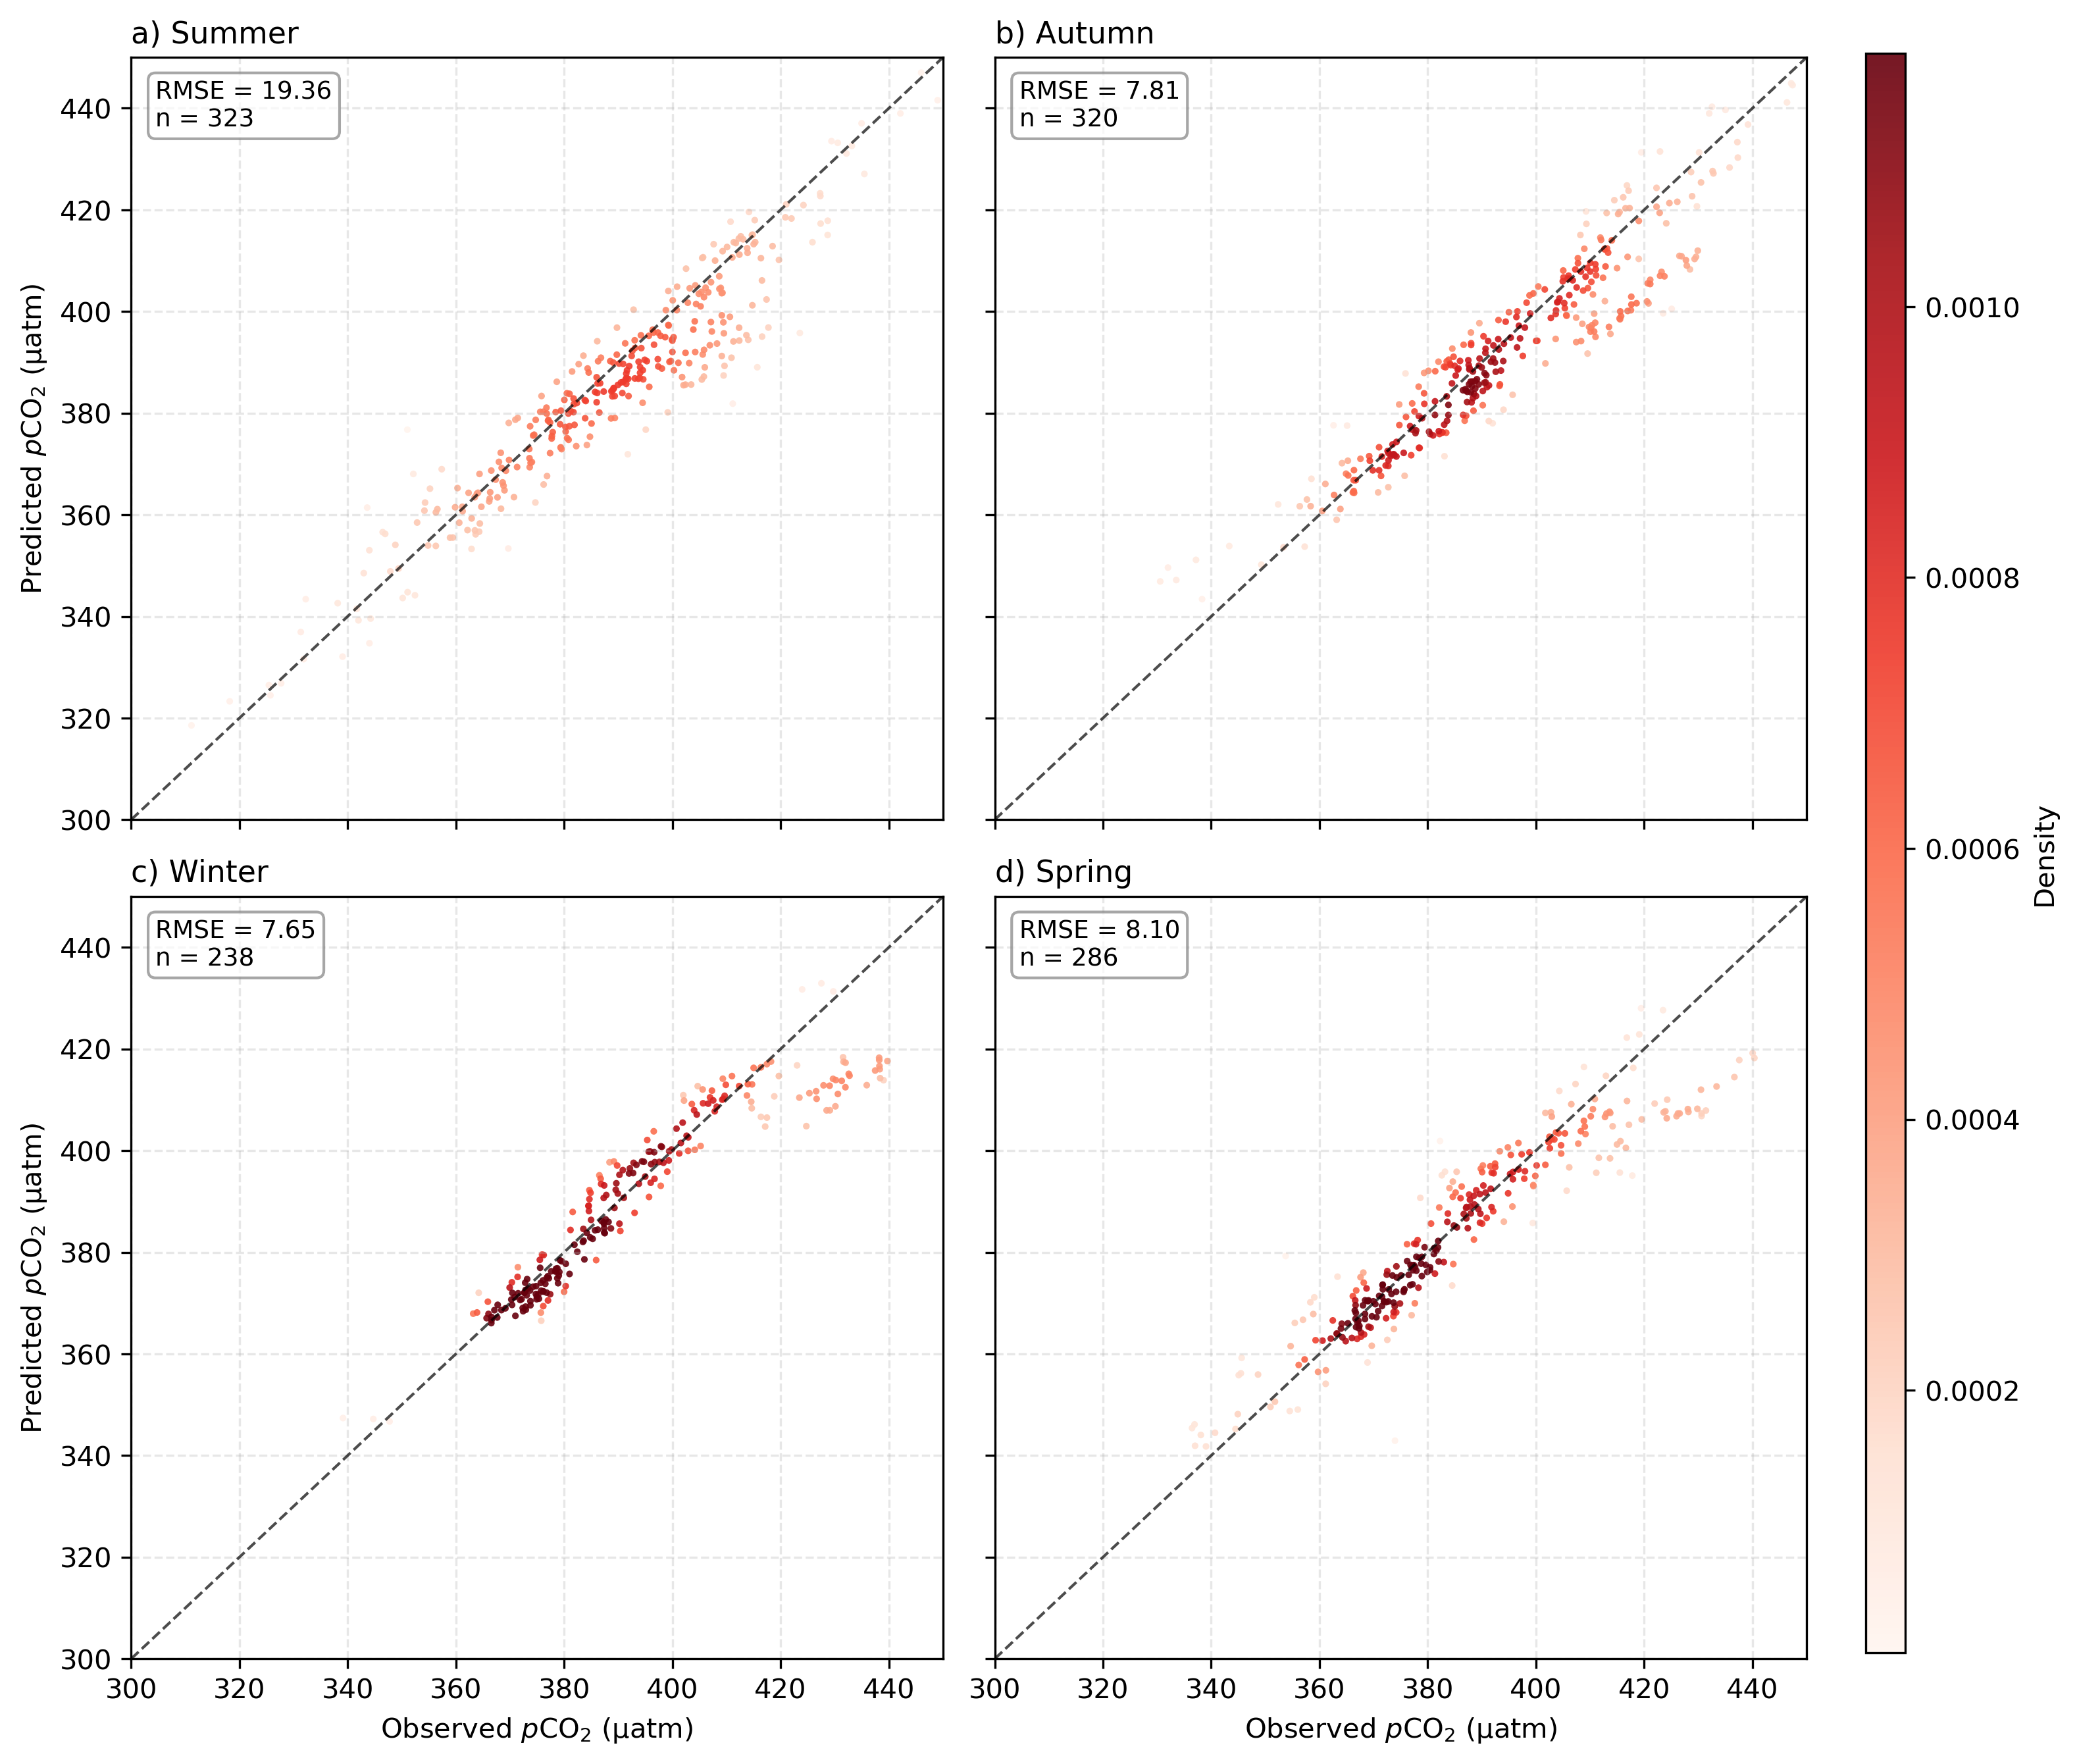

In [19]:
# Prepare subplot grid
fig, axs = plt.subplots(2, 2, figsize=(10, 9), dpi=300, sharex=True, sharey=True)
axs = axs.flatten()

season_order = ['Summer', 'Autumn', 'Winter', 'Spring']
letters = ['a) Summer', 'b) Autumn', 'c) Winter', 'd) Spring']
xlim = ylim = (300, 450)

for i, season in enumerate(season_order):
    ax = axs[i]

    # -------------------------------
    # Select season & drop NaNs safely
    # -------------------------------
    data = df.loc[df['season'] == season, ['FLOATS_pco2_median', 'ensemble_pco2_pred']].dropna()

    # If too few points, skip safely
    if len(data) < 5:
        ax.text(
            0.5, 0.5, f"{season}\nNot enough data",
            transform=ax.transAxes,
            ha='center',
            va='center',
            fontsize=10
        )
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.grid(True, ls='--', alpha=0.3)
        continue

    x = data['FLOATS_pco2_median'].values
    y = data['ensemble_pco2_pred'].values

    # -------------------------------
    # KDE density (NaN-safe)
    # -------------------------------
    xy = np.vstack([x, y])
    density = gaussian_kde(xy)(xy)

    idx = density.argsort()
    x, y, density = x[idx], y[idx], density[idx]

    # -------------------------------
    # Scatter plot
    # -------------------------------
    sc = ax.scatter(
        x, y,
        c=density,
        s=6,
        alpha=0.9,
        edgecolor='none',
        cmap='Reds',
        vmin=global_vmin,
        vmax=global_vmax
    )

    # -------------------------------
    # Axes setup
    # -------------------------------
    if i % 2 == 0:
        ax.set_ylabel(r"Predicted $p\mathrm{CO}_2$ $\mathrm{(\mu atm)}$")
    if i >= 2:
        ax.set_xlabel(r"Observed $p\mathrm{CO}_2$ $\mathrm{(\mu atm)}$")

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.grid(True, ls='--', alpha=0.3)

    # -------------------------------
    # 1:1 line
    # -------------------------------
    ax.plot([xlim[0], xlim[1]], [ylim[0], ylim[1]], 'k--', lw=1, alpha=0.7)

    # -------------------------------
    # Metrics (sklearn v1.5+ compatible)
    # -------------------------------
    rmse = np.sqrt(mean_squared_error(x, y))
    n = len(x)

    # -------------------------------
    # Stats box
    # -------------------------------
    stats_text = f"RMSE = {rmse:.2f}\nn = {n}"

    ax.text(
        0.03, 0.97,
        stats_text,
        transform=ax.transAxes,
        fontsize=9,
        va='top',
        ha='left',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
    )

    # -------------------------------
    # Panel label
    # -------------------------------
    ax.text(
        0, 1.05,
        letters[i],
        transform=ax.transAxes,
        fontsize=11,
        va='top',
        ha='left'
    )

# -------------------------------
# Shared colorbar
# -------------------------------
cbar_ax = fig.add_axes([0.95, 0.068, 0.02, 0.9])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('Density')

# -------------------------------
# Final layout and save
# -------------------------------
fig.tight_layout()
fig.subplots_adjust(right=0.92)
fig.savefig("figs/pco2_density_by_season.png", dpi=300, bbox_inches='tight')
plt.show()


## Scatter plots saisons pour test df

In [20]:
# Import test df
df = pd.read_csv(
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_FLOATS_v2/models/MC_ensemble/independent_predictions/MC_FLOATS_independent_validation_predictions.csv"
)

# Prepare subplot grid
fig, axs = plt.subplots(2, 2, figsize=(10, 9), dpi=300, sharex=True, sharey=True)
axs = axs.flatten()

season_order = ['Summer', 'Autumn', 'Winter', 'Spring']
letters = ['a) Summer', 'b) Autumn', 'c) Winter', 'd) Spring']
xlim = ylim = (300, 450)

for i, season in enumerate(season_order):
    ax = axs[i]

    # -------------------------------
    # Select season & drop NaNs safely
    # -------------------------------
    data = df.loc[df['season'] == season, ['FLOATS_pco2_median', 'ensemble_pco2_pred']].dropna()

    # If too few points, skip safely
    if len(data) < 5:
        ax.text(
            0.5, 0.5, f"{season}\nNot enough data",
            transform=ax.transAxes,
            ha='center',
            va='center',
            fontsize=10
        )
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.grid(True, ls='--', alpha=0.3)
        continue

    x = data['FLOATS_pco2_median'].values
    y = data['ensemble_pco2_pred'].values

    # -------------------------------
    # KDE density (NaN-safe)
    # -------------------------------
    xy = np.vstack([x, y])
    density = gaussian_kde(xy)(xy)

    idx = density.argsort()
    x, y, density = x[idx], y[idx], density[idx]

    # -------------------------------
    # Scatter plot
    # -------------------------------
    sc = ax.scatter(
        x, y,
        c=density,
        s=6,
        alpha=0.9,
        edgecolor='none',
        cmap='Reds',
        vmin=global_vmin,
        vmax=global_vmax
    )

    # -------------------------------
    # Axes setup
    # -------------------------------
    if i % 2 == 0:
        ax.set_ylabel(r"Predicted $p\mathrm{CO}_2$ $\mathrm{(\mu atm)}$")
    if i >= 2:
        ax.set_xlabel(r"Observed $p\mathrm{CO}_2$ $\mathrm{(\mu atm)}$")

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.grid(True, ls='--', alpha=0.3)

    # -------------------------------
    # 1:1 line
    # -------------------------------
    ax.plot([xlim[0], xlim[1]], [ylim[0], ylim[1]], 'k--', lw=1, alpha=0.7)

    # -------------------------------
    # Metrics (sklearn v1.5+ compatible)
    # -------------------------------
    rmse = np.sqrt(mean_squared_error(x, y))
    n = len(x)

    # -------------------------------
    # Stats box
    # -------------------------------
    stats_text = f"RMSE = {rmse:.2f}\nn = {n}"

    ax.text(
        0.03, 0.97,
        stats_text,
        transform=ax.transAxes,
        fontsize=9,
        va='top',
        ha='left',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
    )

    # -------------------------------
    # Panel label
    # -------------------------------
    ax.text(
        0, 1.05,
        letters[i],
        transform=ax.transAxes,
        fontsize=11,
        va='top',
        ha='left'
    )

# -------------------------------
# Shared colorbar
# -------------------------------
cbar_ax = fig.add_axes([0.95, 0.068, 0.02, 0.9])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('Density')

# -------------------------------
# Final layout and save
# -------------------------------
fig.tight_layout()
fig.subplots_adjust(right=0.92)
fig.savefig("figs/pco2_density_by_season.png", dpi=300, bbox_inches='tight')
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_FLOATS_v2/models/MC_ensemble/independent_predictions/MC_FLOATS_independent_validation_predictions.csv'